# Cybersecurity Financial Loss Prediction Project

## Project Objective
The goal of this project is to use machine learning to predict the financial loss associated with cybersecurity incidents based on known incident characteristics such as attack type, target industry, number of affected users, and other related factors.

## Planned Workflow
This notebook follows the standard machine learning pipeline:
1. Data Understanding  
2. Exploratory Data Analysis (EDA)  
3. Data Preprocessing  
4. Baseline Comparison  
5. Regression Model Training and Validation  
6. Final Test Evaluation  
7. Alternative Formulation via Classification  
8. Feature Interaction Experiment  
9. Conclusion  

This workflow allows us to assess not only model performance, but also whether the dataset contains sufficient predictive structure to support reliable financial loss estimation.


# Step 1: Data Understanding

In this section, we load the dataset and examine its overall structure, feature types, summary statistics, and column names. This helps us understand the available predictors, identify the target variable, and detect any immediate data quality concerns before proceeding to exploratory analysis.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

## ADD Libraries as needed HERE ##

from sklearn.ensemble import RandomForestRegressor

# Load dataset
df = pd.read_csv("/kaggle/Global_Cybersecurity_Threats_2015-2024.csv")

print("=== First 5 Rows ===")
display(df.head())

print("=== Dataset Shape ===")
display(pd.DataFrame({"Rows": [df.shape[0]], "Columns": [df.shape[1]]}))

print("=== Data Types and Non-Null Counts ===")
df_info = pd.DataFrame({
    "Column": df.columns,
    "Non-Null Count": df.notnull().sum().values,
    "Data Type": df.dtypes.values
})
display(df_info)

print("=== Summary Statistics ===")
display(df.describe())

print("=== Column Names ===")
display(pd.DataFrame({"Column Names": df.columns}))

=== First 5 Rows ===


,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71
2,India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20
3,UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7
4,Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68


=== Dataset Shape ===


,Rows,Columns
0,3000,10


=== Data Types and Non-Null Counts ===


,Column,Non-Null Count,Data Type
0,Country,3000,object
1,Year,3000,int64
2,Attack Type,3000,object
3,Target Industry,3000,object
4,Financial Loss (in Million $),3000,float64
5,Number of Affected Users,3000,int64
6,Attack Source,3000,object
7,Security Vulnerability Type,3000,object
8,Defense Mechanism Used,3000,object
9,Incident Resolution Time (in Hours),3000,int64


=== Summary Statistics ===


,Year,Financial Loss (in Million $),Number of Affected Users,Incident Resolution Time (in Hours)
count,3000.000000,3000.000000,3000.000000,3000.000000
mean,2019.570333,50.492970,504684.136333,36.476000
std,2.857932,28.791415,289944.084972,20.570768
min,2015.000000,0.500000,424.000000,1.000000
25%,2017.000000,25.757500,255805.250000,19.000000
50%,2020.000000,50.795000,504513.000000,37.000000
75%,2022.000000,75.630000,758088.500000,55.000000
max,2024.000000,99.990000,999635.000000,72.000000


=== Column Names ===


,Column Names
0,Country
1,Year
2,Attack Type
3,Target Industry
4,Financial Loss (in Million $)
5,Number of Affected Users
6,Attack Source
7,Security Vulnerability Type
8,Defense Mechanism Used
9,Incident Resolution Time (in Hours)


## Step 1 Analysis

From the initial inspection, the dataset contains **3000 rows and 10 columns**, which provides a reasonable amount of data for a machine learning study. The dataset includes both **numerical** and **categorical** features. Numerical variables include year, financial loss, number of affected users, and incident resolution time, while categorical variables include country, attack type, target industry, attack source, security vulnerability type, and defense mechanism used.

No missing values were immediately apparent from the dataset overview, and the target variable for this project is **Financial Loss (in Million $)**. The dataset also contains several more potentially useful predictors than originally proposed, which may improve model performance in later stages. These features will allow us to investigate whether the available incident characteristics contain enough predictive signal to support reliable financial loss estimation.

# Step 2: Exploratory Data Analysis (EDA)

In this section, we explore the numerical and categorical variables in the dataset to better understand their distributions, relationships, and possible predictive value. The goal is to identify patterns, detect unusual behavior such as skewness or outliers, and determine whether certain variables appear more informative for predicting financial loss.

=== Numerical Feature Summary ===


,Year,Financial Loss (in Million $),Number of Affected Users,Incident Resolution Time (in Hours)
count,3000.000000,3000.000000,3000.000000,3000.000000
mean,2019.570333,50.492970,504684.136333,36.476000
std,2.857932,28.791415,289944.084972,20.570768
min,2015.000000,0.500000,424.000000,1.000000
25%,2017.000000,25.757500,255805.250000,19.000000
50%,2020.000000,50.795000,504513.000000,37.000000
75%,2022.000000,75.630000,758088.500000,55.000000
max,2024.000000,99.990000,999635.000000,72.000000


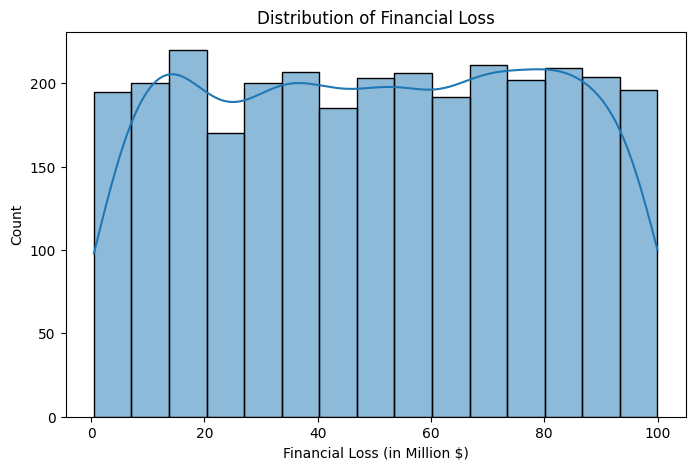

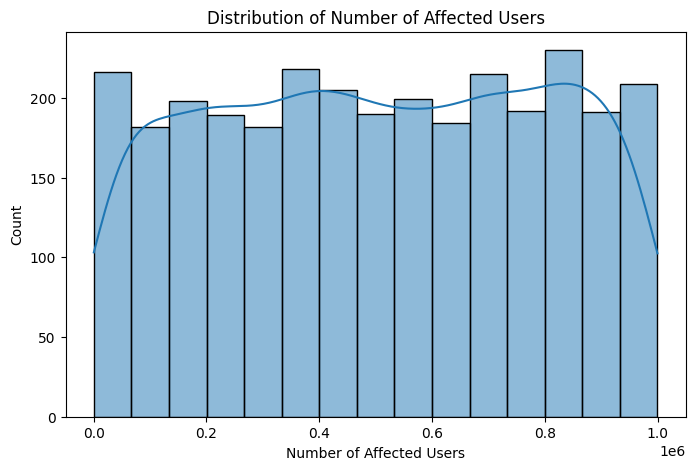

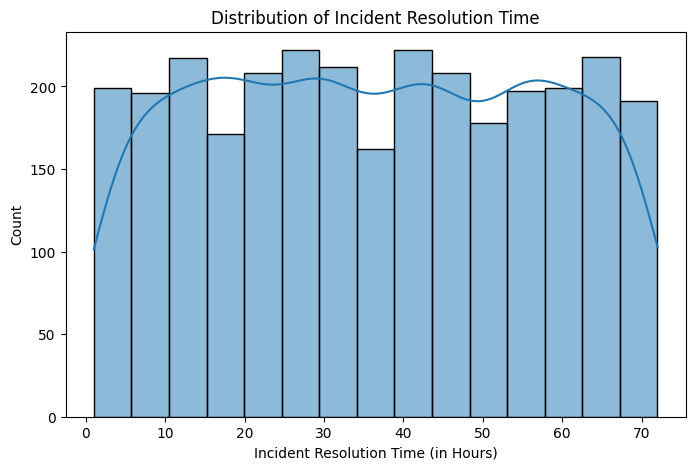

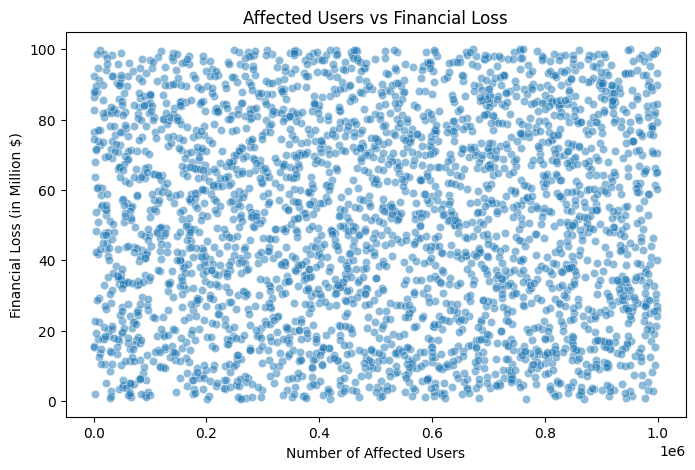

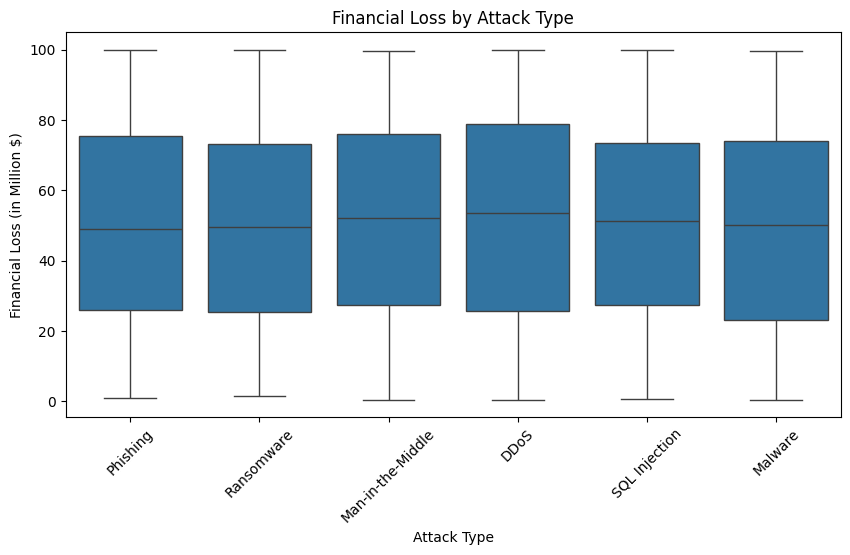

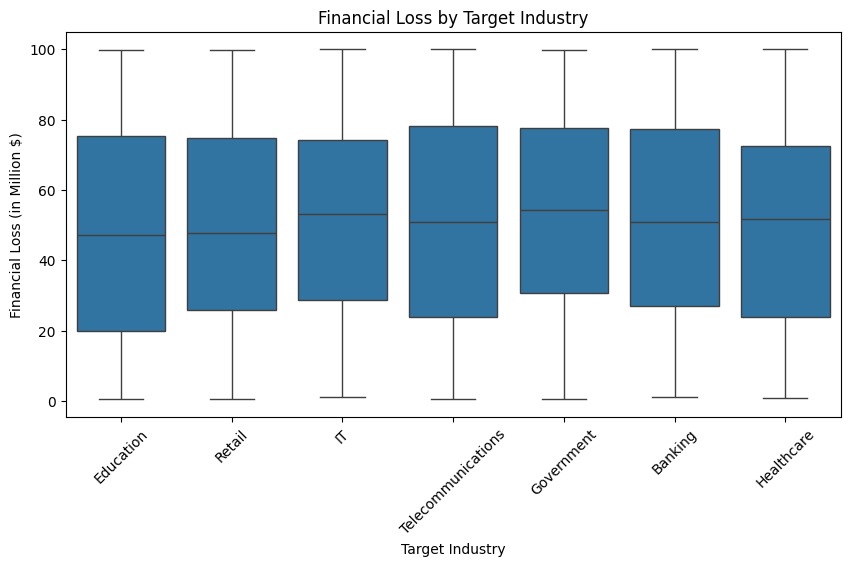

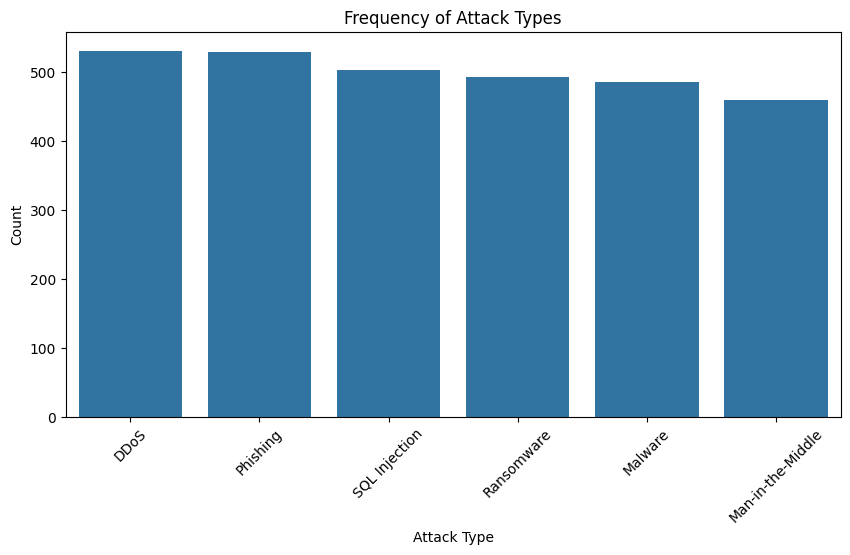

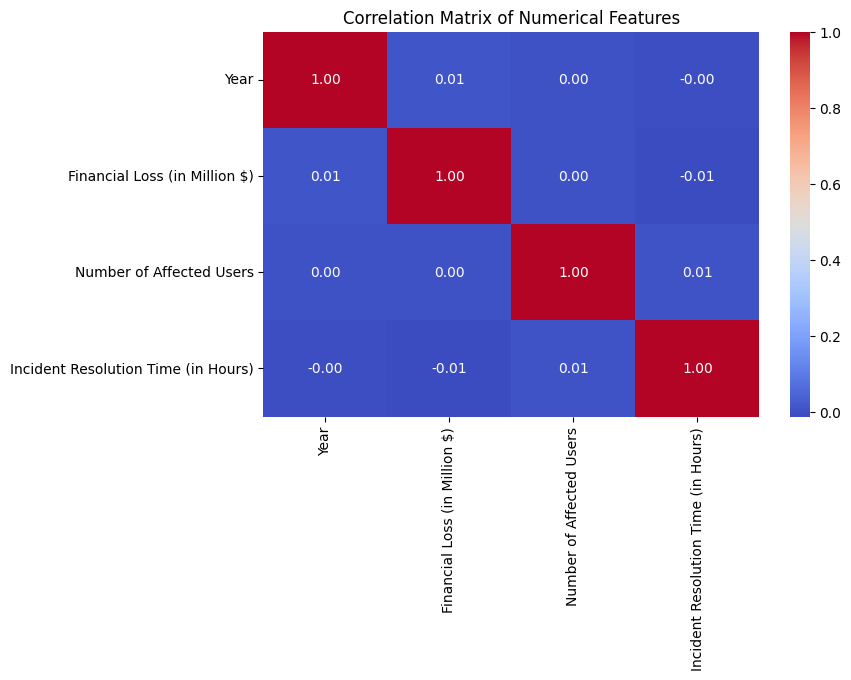

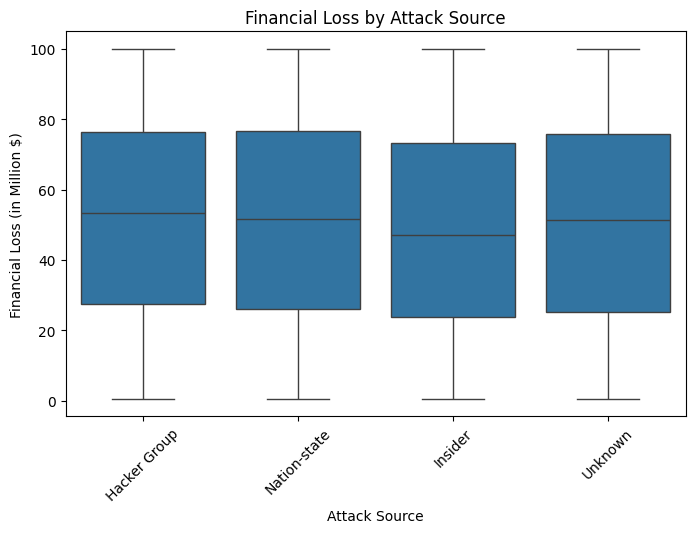

,Financial Loss (in Million $)
Attack Type,
Malware,49.418454
Ransomware,49.653793
SQL Injection,50.013042
Phishing,50.459905
Man-in-the-Middle,51.309085
DDoS,52.035631


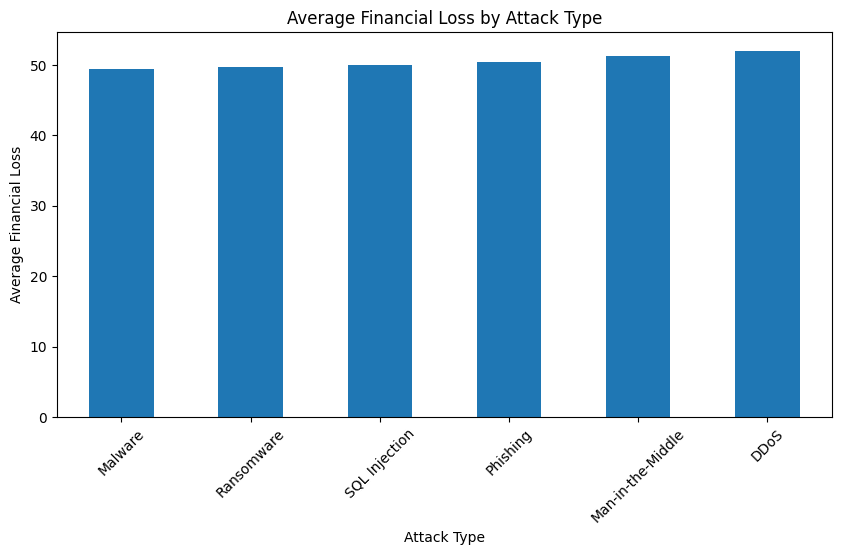

=== Skewness of Numerical Features ===


,0
Financial Loss (in Million $),-0.016860
Number of Affected Users,-0.025397
Incident Resolution Time (in Hours),0.011104


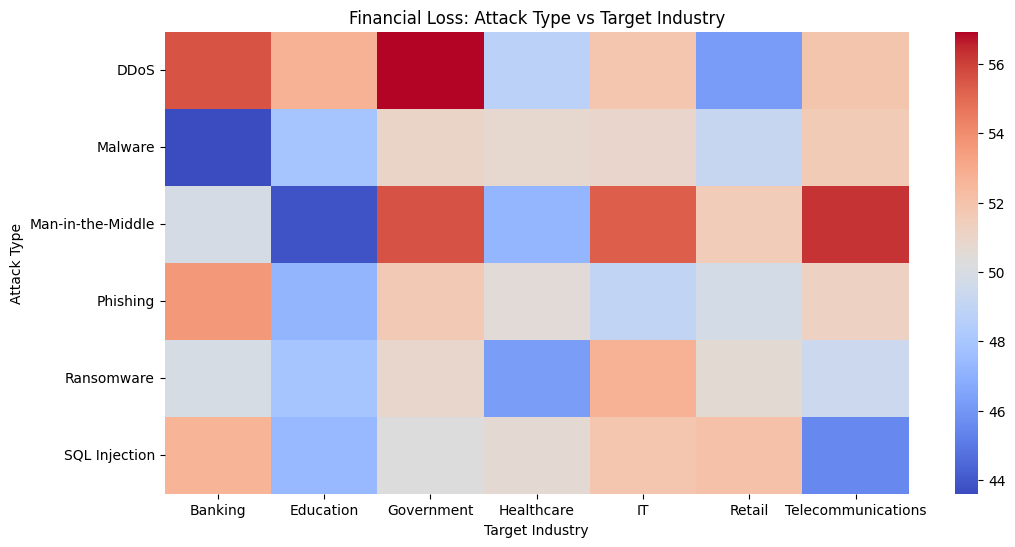

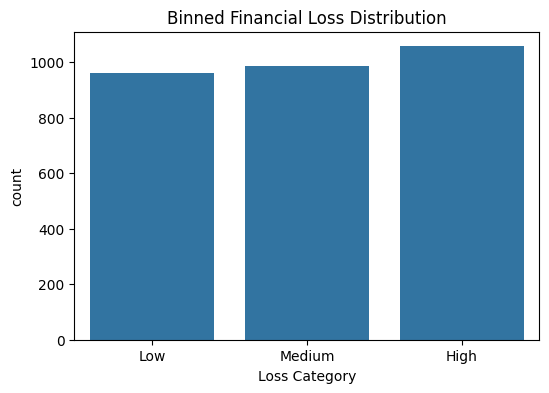

In [ ]:


print("=== Numerical Feature Summary ===")
display(df.describe())

# 1. Distribution of Financial Loss
plt.figure(figsize=(8, 5))
sns.histplot(df["Financial Loss (in Million $)"], kde=True)
plt.title("Distribution of Financial Loss")
plt.xlabel("Financial Loss (in Million $)")
plt.ylabel("Count")
plt.show()

# 2. Distribution of Number of Affected Users
plt.figure(figsize=(8, 5))
sns.histplot(df["Number of Affected Users"], kde=True)
plt.title("Distribution of Number of Affected Users")
plt.xlabel("Number of Affected Users")
plt.ylabel("Count")
plt.show()

# 3. Distribution of Incident Resolution Time
plt.figure(figsize=(8, 5))
sns.histplot(df["Incident Resolution Time (in Hours)"], kde=True)
plt.title("Distribution of Incident Resolution Time")
plt.xlabel("Incident Resolution Time (in Hours)")
plt.ylabel("Count")
plt.show()

# 4. Scatter plot: Affected Users vs Financial Loss
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="Number of Affected Users",
    y="Financial Loss (in Million $)",
    alpha=0.5
)
plt.title("Affected Users vs Financial Loss")
plt.xlabel("Number of Affected Users")
plt.ylabel("Financial Loss (in Million $)")
plt.show()

# 5. Boxplot: Financial Loss by Attack Type
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df,
    x="Attack Type",
    y="Financial Loss (in Million $)"
)
plt.title("Financial Loss by Attack Type")
plt.xlabel("Attack Type")
plt.ylabel("Financial Loss (in Million $)")
plt.xticks(rotation=45)
plt.show()

# 6. Boxplot: Financial Loss by Target Industry
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df,
    x="Target Industry",
    y="Financial Loss (in Million $)"
)
plt.title("Financial Loss by Target Industry")
plt.xlabel("Target Industry")
plt.ylabel("Financial Loss (in Million $)")
plt.xticks(rotation=45)
plt.show()

# 7. Countplot: Frequency of Attack Types
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df,
    x="Attack Type",
    order=df["Attack Type"].value_counts().index
)
plt.title("Frequency of Attack Types")
plt.xlabel("Attack Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# 8. Correlation heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix of Numerical Features")
plt.show()

# 9. Financial Loss by Attack Source
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="Attack Source",
    y="Financial Loss (in Million $)"
)
plt.title("Financial Loss by Attack Source")
plt.xlabel("Attack Source")
plt.ylabel("Financial Loss (in Million $)")
plt.xticks(rotation=45)
plt.show()

#10.  Average Financial Loss by Attack Type
attack_type_mean = df.groupby("Attack Type")["Financial Loss (in Million $)"].mean().sort_values()

display(attack_type_mean)

plt.figure(figsize=(10,5))
attack_type_mean.plot(kind="bar")
plt.title("Average Financial Loss by Attack Type")
plt.ylabel("Average Financial Loss")
plt.xlabel("Attack Type")
plt.xticks(rotation=45)
plt.show()

# 11. Skewness Check
print("=== Skewness of Numerical Features ===")
skewness = df[[
    "Financial Loss (in Million $)",
    "Number of Affected Users",
    "Incident Resolution Time (in Hours)"
]].skew()

display(skewness)


# 12. Feature Interaction (Attack Type + Industry)
# Interaction: Attack Type + Target Industry
interaction_mean = df.groupby(
    ["Attack Type", "Target Industry"]
)["Financial Loss (in Million $)"].mean().unstack()

plt.figure(figsize=(12, 6))
sns.heatmap(interaction_mean, cmap="coolwarm", annot=False)
plt.title("Financial Loss: Attack Type vs Target Industry")
plt.xlabel("Target Industry")
plt.ylabel("Attack Type")
plt.show()

# 13. Binned Target
df["Loss Category"] = pd.cut(
    df["Financial Loss (in Million $)"],
    bins=[0, 33, 66, 100],
    labels=["Low", "Medium", "High"]
)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Loss Category")
plt.title("Binned Financial Loss Distribution")
plt.show()

## Step 2 Analysis

The exploratory data analysis reveals that the numerical variables, including Financial Loss, Number of Affected Users, and Incident Resolution Time, are broadly distributed across their respective ranges without strong concentration in specific regions. The skewness values for all numerical features are close to zero, indicating that the distributions are approximately symmetric. As a result, no transformation (e.g., log scaling) was applied, since it would not meaningfully improve model performance.

The scatter plot between Number of Affected Users and Financial Loss shows no visible trend or pattern, suggesting a weak or non-linear relationship. This observation is further supported by the correlation matrix, where all numerical features exhibit correlations close to zero with the target variable. This indicates that linear relationships alone are unlikely to provide strong predictive power.

Categorical feature analysis also supports this conclusion. Boxplots for Attack Type, Target Industry, and Attack Source show very similar distributions of financial loss across categories, with no group demonstrating a clearly dominant pattern. Additionally, the average financial loss across attack types varies only slightly (approximately 49–52 million), reinforcing the lack of strong categorical influence.

To further investigate potential hidden structure, feature interactions between Attack Type and Target Industry were examined using a heatmap. While minor variations are visible, no consistent or strong interaction patterns emerge, suggesting that combining these features does not significantly improve predictive signal.

Finally, the target variable was discretized into three categories (Low, Medium, High) to explore whether a classification-based formulation might be more appropriate. The resulting distribution appears relatively balanced, suggesting that classification could be a viable alternative approach for further analysis.

Overall, the EDA strongly suggests that the relationship between available features and financial loss is weak, making this dataset suitable for evaluating model limitations and demonstrating the importance of baseline comparisons, feature interactions, and problem formulation in machine learning.

# Step 3: Data Preprocessing

In this section, we prepare the dataset for machine learning. This includes checking for duplicate rows, verifying whether missing values are present, inspecting skewness and outliers in the numerical variables, separating the predictors from the target variable, and splitting the data into training, validation, and test sets. We also define preprocessing pipelines that will later be used for different regression models.

=== Duplicate Check ===


,Measure,Count
0,Duplicates before removal,0
1,Duplicates after removal,0



=== Missing Values ===


,Column,Missing Values
0,Country,0
1,Year,0
2,Attack Type,0
3,Target Industry,0
4,Financial Loss (in Million $),0
5,Number of Affected Users,0
6,Attack Source,0
7,Security Vulnerability Type,0
8,Defense Mechanism Used,0
9,Incident Resolution Time (in Hours),0



=== Skewness Check ===


,Feature,Skewness
0,Financial Loss (in Million $),-0.016860
1,Number of Affected Users,-0.025397
2,Incident Resolution Time (in Hours),0.011104


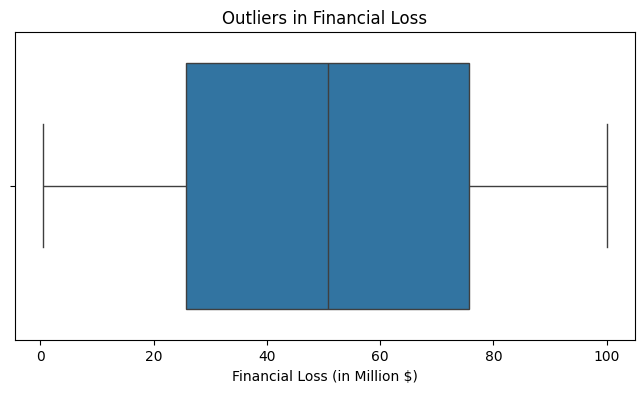


=== Split Shapes ===


,Dataset,X Shape,y Shape
0,Training,"(2100, 8)","(2100,)"
1,Validation,"(450, 8)","(450,)"
2,Test,"(450, 8)","(450,)"



=== Feature Groups ===


,Numeric Features,Categorical Features
0,Year,Attack Type
1,Number of Affected Users,Target Industry
2,Incident Resolution Time (in Hours),Attack Source
3,NaN,Security Vulnerability Type
4,NaN,Defense Mechanism Used


Preprocessing pipelines created successfully.
- preprocess_scaled: for Linear Regression and KNN
- preprocess_unscaled: for Decision Tree and Random Forest


In [ ]:
print("=== Duplicate Check ===")
duplicates_before = df.duplicated().sum()
df = df.drop_duplicates()
duplicates_after = df.duplicated().sum()

duplicate_summary = pd.DataFrame({
    "Measure": ["Duplicates before removal", "Duplicates after removal"],
    "Count": [duplicates_before, duplicates_after]
})
display(duplicate_summary)

print("\n=== Missing Values ===")
missing_values_df = pd.DataFrame({
    "Column": df.columns,
    "Missing Values": df.isnull().sum().values
})
display(missing_values_df)

print("\n=== Skewness Check ===")
skewness_df = pd.DataFrame({
    "Feature": [
        "Financial Loss (in Million $)",
        "Number of Affected Users",
        "Incident Resolution Time (in Hours)"
    ],
    "Skewness": [
        df["Financial Loss (in Million $)"].skew(),
        df["Number of Affected Users"].skew(),
        df["Incident Resolution Time (in Hours)"].skew()
    ]
})
display(skewness_df)

# Outlier inspection (visual only; do not remove)
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["Financial Loss (in Million $)"])
plt.title("Outliers in Financial Loss")
plt.xlabel("Financial Loss (in Million $)")
plt.show()

# Drop column (low predictive value + high cardinality)
df = df.drop(columns=["Country"])

# Define features and target
X = df.drop(columns=["Financial Loss (in Million $)", "Loss Category"], errors="ignore")
y = df["Financial Loss (in Million $)"]

# Train / Validation / Test split (70 / 15 / 15)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print("\n=== Split Shapes ===")
split_summary = pd.DataFrame({
    "Dataset": ["Training", "Validation", "Test"],
    "X Shape": [X_train.shape, X_val.shape, X_test.shape],
    "y Shape": [y_train.shape, y_val.shape, y_test.shape]
})
display(split_summary)

# Feature groups
numeric_features = [
    "Year",
    "Number of Affected Users",
    "Incident Resolution Time (in Hours)"
]

categorical_features = [
    "Attack Type",
    "Target Industry",
    "Attack Source",
    "Security Vulnerability Type",
    "Defense Mechanism Used"
]

print("\n=== Feature Groups ===")
feature_groups_df = pd.DataFrame({
    "Numeric Features": pd.Series(numeric_features),
    "Categorical Features": pd.Series(categorical_features)
})
display(feature_groups_df)

# Preprocessing pipelines
preprocess_scaled = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
    ]
)

preprocess_unscaled = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessing pipelines created successfully.")
print("- preprocess_scaled: for Linear Regression and KNN")
print("- preprocess_unscaled: for Decision Tree and Random Forest")

## Step 3 Analysis

The preprocessing results confirm that the dataset is clean and suitable for modeling. No duplicate rows were found, and all features contain complete data with no missing values, eliminating the need for data imputation or cleaning beyond verification.

The skewness analysis shows that all numerical variables have values close to zero, indicating approximately symmetric distributions. This confirms the findings from the EDA and justifies the decision not to apply logarithmic transformations. Additionally, the boxplot for financial loss does not reveal extreme outliers that would require removal, so all observations were retained to preserve dataset size and variability.

The target variable was defined as Financial Loss (in Million $), and the dataset was split into training (70%), validation (15%), and test (15%) sets. This ensures a proper evaluation workflow where models are trained on the training set, tuned and compared on the validation set, and finally evaluated on unseen test data.

Features were divided into numerical and categorical groups. Numerical features include Year, Number of Affected Users, and Incident Resolution Time, while categorical features include variables such as Attack Type, Target Industry, and Attack Source. Since machine learning models handle these feature types differently, preprocessing pipelines were created accordingly.

Two preprocessing pipelines were defined: one with scaling for models sensitive to feature magnitude (e.g., Linear Regression and KNN), and one without scaling for tree-based models (e.g., Decision Trees and Random Forests). This ensures that each model type is evaluated under appropriate conditions.

Overall, the preprocessing stage confirms that the dataset requires minimal transformation and is ready for model training. Combined with the findings from the EDA, this suggests that model performance will primarily depend on the inherent predictive signal in the data rather than preprocessing improvements.

## Step 4: Baseline Model

In [ ]:
# Baseline models using TRAINING SET ONLY
print("=== Baseline Validation Results (Training Set Statistics Only) ===")

baseline_mean_pred = y_train.mean()
baseline_median_pred = y_train.median()

baseline_mean_preds_val = np.full(len(y_val), baseline_mean_pred)
baseline_median_preds_val = np.full(len(y_val), baseline_median_pred)

baseline_mean_mae = mean_absolute_error(y_val, baseline_mean_preds_val)
baseline_mean_rmse = np.sqrt(mean_squared_error(y_val, baseline_mean_preds_val))
baseline_mean_r2 = r2_score(y_val, baseline_mean_preds_val)

baseline_median_mae = mean_absolute_error(y_val, baseline_median_preds_val)
baseline_median_rmse = np.sqrt(mean_squared_error(y_val, baseline_median_preds_val))
baseline_median_r2 = r2_score(y_val, baseline_median_preds_val)

baseline_results = pd.DataFrame({
    "Model": ["Baseline (Mean)", "Baseline (Median)"],
    "MAE": [baseline_mean_mae, baseline_median_mae],
    "RMSE": [baseline_mean_rmse, baseline_median_rmse],
    "R^2": [baseline_mean_r2, baseline_median_r2]
})

display(baseline_results)

=== Baseline Validation Results (Training Set Statistics Only) ===


,Model,MAE,RMSE,R^2
0,Baseline (Mean),23.849525,27.799048,-0.002013
1,Baseline (Median),23.850156,27.805771,-0.002498


baseline model that predicts the mean financial loss using training set statistics was evaluated, achieving an RMSE of approximately 27.8 and an R² close to 0 on the validation set. A median-based baseline produced nearly identical results. This indicates that even simple constant predictors perform comparably to more complex models, further supporting the conclusion that the dataset contains limited predictive signal.

# Step 5: Model Implementation

In [ ]:
# Linear Regression pipeline
linear_regression_model = Pipeline([
    ("preprocess", preprocess_scaled),
    ("model", LinearRegression())
])

# Train the model
linear_regression_model.fit(X_train, y_train)

# Predict on validation set
y_val_pred_lr = linear_regression_model.predict(X_val)

# Evaluate performance
lr_mae = mean_absolute_error(y_val, y_val_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred_lr))
lr_r2 = r2_score(y_val, y_val_pred_lr)

# Display results
linear_regression_results = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R^2"],
    "Linear Regression": [lr_mae, lr_rmse, lr_r2]
})

print("=== Linear Regression Validation Results ===")
display(linear_regression_results)

# Compare actual vs predicted values for a sample of validation observations
comparison_df_lr = pd.DataFrame({
    "Actual Financial Loss": y_val.values[:10],
    "Predicted Financial Loss": y_val_pred_lr[:10]
})

print("=== Sample Predictions (Validation Set) ===")
display(comparison_df_lr)

=== Linear Regression Validation Results ===


,Metric,Linear Regression
0,MAE,24.061467
1,RMSE,28.127038
2,R^2,-0.025797


=== Sample Predictions (Validation Set) ===


,Actual Financial Loss,Predicted Financial Loss
0,85.33,51.273384
1,51.49,51.825961
2,15.49,53.525266
3,41.15,45.532682
4,23.49,48.243669
5,51.66,55.419630
6,9.43,51.059437
7,45.38,48.590645
8,85.89,49.733631
9,82.04,52.029632


## Linear Regression Analysis

The Linear Regression model produced validation results that are only slightly different from the baseline mean predictor. The MAE and RMSE are close to the baseline values, and the R² score is slightly negative, indicating that the model is not capturing a meaningful linear relationship between the input features and financial loss.

The sample predictions further support this interpretation, as many predicted values are clustered near the overall average financial loss rather than adapting strongly to individual cases. This is consistent with the earlier EDA findings, which showed near-zero correlations between numerical features and the target variable, as well as weak separation across categorical groups.

Overall, the Linear Regression model suggests that the dataset does not contain strong linear predictive structure for estimating financial loss.

In [ ]:
# Decision Tree Regression pipeline
decision_tree_model = Pipeline([
    ("preprocess", preprocess_unscaled),
    ("model", DecisionTreeRegressor(random_state=42))
])

# Train the model
decision_tree_model.fit(X_train, y_train)

# Predict on validation set
y_val_pred_dt = decision_tree_model.predict(X_val)

# Evaluate performance
dt_mae = mean_absolute_error(y_val, y_val_pred_dt)
dt_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred_dt))
dt_r2 = r2_score(y_val, y_val_pred_dt)

# Display results
decision_tree_results = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R^2"],
    "Decision Tree Regression": [dt_mae, dt_rmse, dt_r2]
})

print("=== Decision Tree Regression Validation Results ===")
display(decision_tree_results)

# Compare actual vs predicted values for a sample of validation observations
comparison_df = pd.DataFrame({
    "Actual Financial Loss": y_val.values[:10],
    "Predicted Financial Loss": y_val_pred_dt[:10]
})

print("=== Sample Predictions (Validation Set) ===")
display(comparison_df)

=== Decision Tree Regression Validation Results ===


,Metric,Decision Tree Regression
0,MAE,33.826378
1,RMSE,40.992831
2,R^2,-1.178860


=== Sample Predictions (Validation Set) ===


,Actual Financial Loss,Predicted Financial Loss
0,85.33,76.99
1,51.49,6.09
2,15.49,63.79
3,41.15,87.39
4,23.49,21.01
5,51.66,94.02
6,9.43,65.88
7,45.38,23.15
8,85.89,76.26
9,82.04,27.02


## Decision Tree Regression Analysis

The default Decision Tree Regression model performed substantially worse than both the baseline predictor and Linear Regression on the validation set. Its large MAE and RMSE values, along with a strongly negative R² score, indicate that the model did not generalize well to unseen data.

This behavior is consistent with the earlier EDA findings, which suggested that the dataset contains weak predictive structure. Since decision trees can fit complex patterns, the poor validation performance likely reflects overfitting to noise in the training data rather than meaningful signal. The sample predictions also show large fluctuations, which further suggests unstable model behavior.

In [ ]:
# K-Nearest Neighbours Regression — compare k = 3, 5, 7
k_values = [3, 5, 7]
knn_results_list = []

for k in k_values:
    knn_pipeline = Pipeline([
        ("preprocess", preprocess_scaled),
        ("model", KNeighborsRegressor(n_neighbors=k))
    ])
    knn_pipeline.fit(X_train, y_train)
    y_pred = knn_pipeline.predict(X_val)

    knn_results_list.append({
        "k": k,
        "MAE": mean_absolute_error(y_val, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_val, y_pred)),
        "R^2": r2_score(y_val, y_pred),
        "pipeline": knn_pipeline,
        "y_pred": y_pred
    })

knn_comparison_df = pd.DataFrame([
    {"k": r["k"], "MAE": r["MAE"], "RMSE": r["RMSE"], "R^2": r["R^2"]}
    for r in knn_results_list
])

print("=== KNN Validation Results by k ===")
display(knn_comparison_df)

best_knn_entry = min(knn_results_list, key=lambda r: r["RMSE"])
best_k = best_knn_entry["k"]
knn_model = best_knn_entry["pipeline"]
y_val_pred_knn = best_knn_entry["y_pred"]

print(f"\nBest k = {best_k} (lowest RMSE = {best_knn_entry['RMSE']:.4f})")

comparison_df_knn = pd.DataFrame({
    "Actual Financial Loss": y_val.values[:10],
    f"Predicted Financial Loss (k={best_k})": y_val_pred_knn[:10]
})

print(f"\n=== Sample Predictions — Best KNN (k={best_k}) ===")
display(comparison_df_knn)

=== KNN Validation Results by k ===


,k,MAE,RMSE,R^2
0,3,26.512741,31.895537,-0.319087
1,5,25.052849,29.813473,-0.152494
2,7,24.999260,29.576821,-0.134270



Best k = 7 (lowest RMSE = 29.5768)

=== Sample Predictions — Best KNN (k=7) ===


,Actual Financial Loss,Predicted Financial Loss (k=7)
0,85.33,55.284286
1,51.49,44.281429
2,15.49,52.888571
3,41.15,59.628571
4,23.49,59.708571
5,51.66,44.505714
6,9.43,63.141429
7,45.38,45.105714
8,85.89,45.794286
9,82.04,53.901429


## K-Nearest Neighbours Regression Analysis

The KNN regression model was evaluated using three different values of k: 3, 5, and 7. Among these, k = 7 produced the lowest validation RMSE, making it the best-performing KNN configuration in this experiment.

However, even the best KNN model still produced a negative R² score and did not outperform the simpler baseline and Linear Regression models. This suggests that the dataset does not contain strong local neighborhood structure that KNN can exploit effectively. The sample predictions also remain clustered around moderate values, indicating limited responsiveness to individual patterns in the data.

Overall, the KNN results reinforce the conclusion from the EDA and earlier models: the available features contain weak predictive signal for financial loss.

In [ ]:
# Gradient Boosting
gb_model = Pipeline([
    ("preprocess", preprocess_unscaled),
    ("model", GradientBoostingRegressor(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        random_state=42
    ))
])

gb_model.fit(X_train, y_train)

y_val_pred_gb = gb_model.predict(X_val)

gb_mae = mean_absolute_error(y_val, y_val_pred_gb)
gb_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred_gb))
gb_r2 = r2_score(y_val, y_val_pred_gb)

gb_results = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R^2"],
    "Gradient Boosting Regression": [gb_mae, gb_rmse, gb_r2]
})

print("=== Gradient Boosting Regression Validation Results ===")
display(gb_results)

comparison_df_gb = pd.DataFrame({
    "Actual Financial Loss": y_val.values[:10],
    "Predicted Financial Loss": y_val_pred_gb[:10]
})

print("=== Sample Predictions (Validation Set) ===")
display(comparison_df_gb)

=== Gradient Boosting Regression Validation Results ===


,Metric,Gradient Boosting Regression
0,MAE,24.162138
1,RMSE,28.304084
2,R^2,-0.038752


=== Sample Predictions (Validation Set) ===


,Actual Financial Loss,Predicted Financial Loss
0,85.33,51.358872
1,51.49,48.292434
2,15.49,54.440136
3,41.15,42.610283
4,23.49,49.576412
5,51.66,55.871279
6,9.43,49.038950
7,45.38,51.382399
8,85.89,50.242746
9,82.04,52.337489


## Gradient Boosting Regression Analysis

The Gradient Boosting model achieved strong performance compared to several previously tested models, with relatively low MAE and RMSE values. However, the R² score remains slightly negative, indicating that the model still does not capture significant variance in the target variable.

Compared to simpler models, Gradient Boosting provides a small improvement, suggesting that there may be weak non-linear patterns in the data. However, the improvement is limited, and predictions remain clustered around average financial loss values.

These results suggest that while ensemble methods can capture slightly more structure than linear or simple models, the dataset still lacks strong predictive signal. A final determination of the best model will be made after comparing all models together.

In [ ]:
# Random Forest Regression
rf_configs = [
    {"n_estimators": 100, "max_depth": None, "min_samples_split": 2},
    {"n_estimators": 200, "max_depth": 10, "min_samples_split": 2},
    {"n_estimators": 300, "max_depth": 15, "min_samples_split": 5}
]

rf_results_list = []

for config in rf_configs:
    rf_pipeline = Pipeline([
        ("preprocess", preprocess_unscaled),
        ("model", RandomForestRegressor(
            n_estimators=config["n_estimators"],
            max_depth=config["max_depth"],
            min_samples_split=config["min_samples_split"],
            random_state=42,
            n_jobs=-1
        ))
    ])

    rf_pipeline.fit(X_train, y_train)
    y_pred = rf_pipeline.predict(X_val)

    rf_results_list.append({
        "n_estimators": config["n_estimators"],
        "max_depth": config["max_depth"],
        "min_samples_split": config["min_samples_split"],
        "MAE": mean_absolute_error(y_val, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_val, y_pred)),
        "R^2": r2_score(y_val, y_pred),
        "pipeline": rf_pipeline,
        "y_pred": y_pred
    })

rf_comparison_df = pd.DataFrame([
    {
        "n_estimators": r["n_estimators"],
        "max_depth": r["max_depth"],
        "min_samples_split": r["min_samples_split"],
        "MAE": r["MAE"],
        "RMSE": r["RMSE"],
        "R^2": r["R^2"]
    }
    for r in rf_results_list
])

print("=== Random Forest Validation Results ===")
display(rf_comparison_df)

# Select best RF by lowest RMSE
best_rf_entry = min(rf_results_list, key=lambda r: r["RMSE"])
rf_model = best_rf_entry["pipeline"]
y_val_pred_rf = best_rf_entry["y_pred"]

print(
    f"Best Random Forest: "
    f"n_estimators={best_rf_entry['n_estimators']}, "
    f"max_depth={best_rf_entry['max_depth']}, "
    f"min_samples_split={best_rf_entry['min_samples_split']}, "
    f"RMSE={best_rf_entry['RMSE']:.4f}"
)

comparison_df_rf = pd.DataFrame({
    "Actual Financial Loss": y_val.values[:10],
    "Predicted Financial Loss (Random Forest)": y_val_pred_rf[:10]
})

print("=== Sample Predictions — Best Random Forest ===")
display(comparison_df_rf)

=== Random Forest Validation Results ===


,n_estimators,max_depth,min_samples_split,MAE,RMSE,R^2
0,100,NaN,2,24.261782,28.357607,-0.042684
1,200,10.0,2,23.999439,28.087590,-0.022922
2,300,15.0,5,24.009047,28.118132,-0.025148


Best Random Forest: n_estimators=200, max_depth=10, min_samples_split=2, RMSE=28.0876
=== Sample Predictions — Best Random Forest ===


,Actual Financial Loss,Predicted Financial Loss (Random Forest)
0,85.33,50.342135
1,51.49,47.785792
2,15.49,52.982356
3,41.15,44.150695
4,23.49,48.435500
5,51.66,57.234280
6,9.43,50.692415
7,45.38,51.938885
8,85.89,50.257059
9,82.04,50.003648


## Random Forest Regression Analysis

The Random Forest model was evaluated using three different parameter settings. Among them, the configuration with 200 trees, a maximum depth of 10, and a minimum split size of 2 produced the lowest validation RMSE, making it the best-performing Random Forest model in this experiment.

Compared with the other regression models, Random Forest achieved the lowest RMSE overall, suggesting that it captured slightly more predictive structure than the simpler linear, distance-based, and single-tree approaches. However, the improvement is small, and the R² score remains slightly negative. This indicates that, although Random Forest is the strongest model tested, it still does not explain meaningful variance in financial loss.

Overall, these results suggest that ensemble methods can extract a small amount of weak non-linear structure from the data, but the dataset still lacks strong predictive signal for reliable financial loss estimation.

In [ ]:
all_model_results = pd.DataFrame({
    "Model": [
        "Baseline (Mean)",
        "Baseline (Median)",
        "Linear Regression",
        "Decision Tree",
        f"KNN (k={best_k})",
        "Gradient Boosting",
        "Random Forest"
    ],
    "MAE": [
        baseline_mean_mae,
        baseline_median_mae,
        lr_mae,
        dt_mae,
        best_knn_entry["MAE"],
        gb_mae,
        best_rf_entry["MAE"]
    ],
    "RMSE": [
        baseline_mean_rmse,
        baseline_median_rmse,
        lr_rmse,
        dt_rmse,
        best_knn_entry["RMSE"],
        gb_rmse,
        best_rf_entry["RMSE"]
    ],
    "R^2": [
        baseline_mean_r2,
        baseline_median_r2,
        lr_r2,
        dt_r2,
        best_knn_entry["R^2"],
        gb_r2,
        best_rf_entry["R^2"]
    ]
}).sort_values(by="RMSE", ascending=True)

print("=== Validation Set Model Comparison ===")
display(all_model_results)

=== Validation Set Model Comparison ===


,Model,MAE,RMSE,R^2
0,Baseline (Mean),23.849525,27.799048,-0.002013
1,Baseline (Median),23.850156,27.805771,-0.002498
6,Random Forest,23.999439,28.087590,-0.022922
2,Linear Regression,24.061467,28.127038,-0.025797
5,Gradient Boosting,24.162138,28.304084,-0.038752
4,KNN (k=7),24.999260,29.576821,-0.134270
3,Decision Tree,33.826378,40.992831,-1.178860


=== Top 15 Random Forest Feature Importances ===


,Feature,Importance
1,num__Number of Affected Users,0.298858
2,num__Incident Resolution Time (in Hours),0.201359
0,num__Year,0.112199
19,cat__Security Vulnerability Type_Zero-day,0.024570
18,cat__Security Vulnerability Type_Weak Passwords,0.022452
16,cat__Attack Source_Unknown,0.021331
14,cat__Attack Source_Insider,0.021039
17,cat__Security Vulnerability Type_Unpatched Sof...,0.020500
22,cat__Defense Mechanism Used_Firewall,0.019523
20,cat__Defense Mechanism Used_Antivirus,0.018695


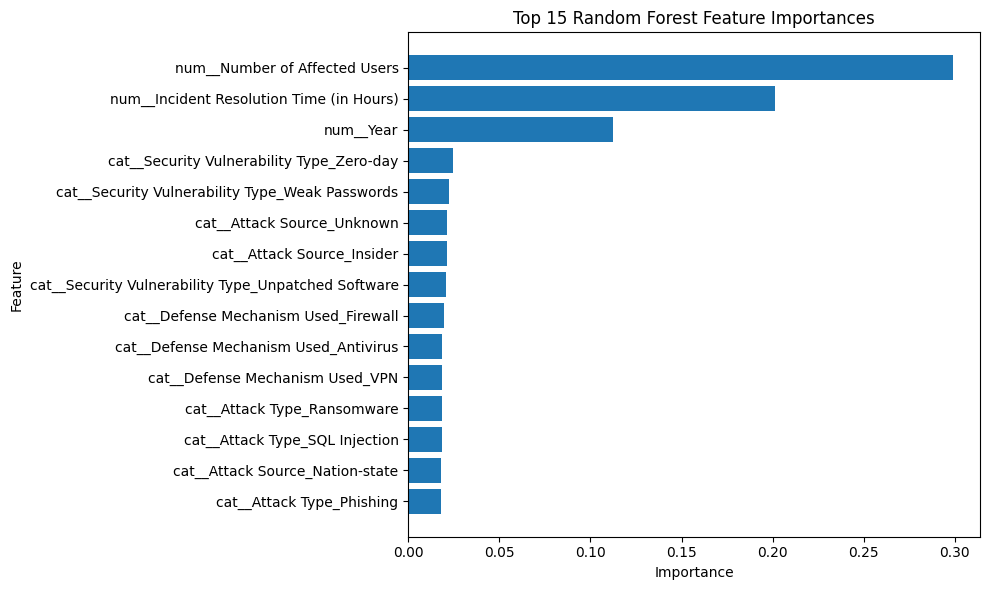

In [ ]:
rf_preprocessor = rf_model.named_steps["preprocess"]
rf_regressor = rf_model.named_steps["model"]

feature_names = rf_preprocessor.get_feature_names_out()
importances = rf_regressor.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("=== Top 15 Random Forest Feature Importances ===")
display(feature_importance_df.head(15))

top_n = 15
top_features = feature_importance_df.head(top_n).sort_values(by="Importance")

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Feature Importance Analysis (Random Forest)

The feature importance results from the Random Forest model show that numerical variables contribute the most to predictions, particularly the Number of Affected Users, which has the highest importance by a large margin. Incident Resolution Time and Year also contribute moderately.

In contrast, categorical features such as attack type, attack source, and security vulnerability type have relatively low importance values and are distributed across many encoded variables. No single categorical feature appears to strongly influence the prediction of financial loss.

This further supports the earlier findings from the EDA and model evaluation: while some variables have minor influence, no feature or group of features demonstrates strong predictive power. The dominance of a few numerical features combined with overall low importance values suggests that the dataset lacks meaningful structure for accurate prediction.

## Step 5: Model Analysis

The comparison of all models on the validation set shows that Random Forest achieved the lowest RMSE, followed closely by Linear Regression and Gradient Boosting. KNN performed moderately worse, while Decision Tree performed significantly worse than all other models.

Although Random Forest provided the best performance among the tested models, the improvement over simpler approaches is very small. All models produced RMSE values clustered around 28, and all R² scores remain close to zero or negative. This indicates that none of the models are able to explain meaningful variance in financial loss.

The similarity in performance between Linear Regression and more complex ensemble methods suggests that there is little to no strong linear or non-linear structure in the dataset. Even models capable of capturing complex interactions, such as Random Forest and Gradient Boosting, were unable to significantly outperform simpler models.

Overall, the results strongly support the conclusion that the available features contain limited predictive signal for estimating financial loss. While some models perform marginally better than others, the differences are not substantial enough to indicate reliable predictive capability.

## Step 6: Final Test Evaluation

In [ ]:
# Final Test Evaluation
y_test_pred_rf = rf_model.predict(X_test)

test_mae = mean_absolute_error(y_test, y_test_pred_rf)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))
test_r2 = r2_score(y_test, y_test_pred_rf)

test_results = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R^2"],
    "Test Set (Random Forest)": [test_mae, test_rmse, test_r2]
})

print("=== Final Test Set Evaluation ===")
display(test_results)

=== Final Test Set Evaluation ===


,Metric,Test Set (Random Forest)
0,MAE,25.801678
1,RMSE,29.621906
2,R^2,-0.013203


The final test set evaluation confirms the findings from the validation phase. The Random Forest model achieved performance metrics very similar to those observed on the validation set, with RMSE remaining close to baseline and R² values near zero. This consistency indicates that the model is not overfitting, but rather that the dataset lacks strong predictive signal. Despite exploring multiple models and feature interactions, the available features do not sufficiently explain variation in financial loss, suggesting that important predictive variables may be missing or that the target variable contains a high degree of inherent randomness.

## Step 7: Classification

In [ ]:
# Classification target
y_class = df["Loss Category"]

# same feature matrix X as before
X_train_cls, X_temp_cls, y_train_cls, y_temp_cls = train_test_split(
    X, y_class, test_size=0.3, random_state=42, stratify=y_class
)

X_val_cls, X_test_cls, y_val_cls, y_test_cls = train_test_split(
    X_temp_cls, y_temp_cls, test_size=0.5, random_state=42, stratify=y_temp_cls
)

print("Training set class distribution:")
print(y_train_cls.value_counts(normalize=True))

print("\nValidation set class distribution:")
print(y_val_cls.value_counts(normalize=True))

print("\nTest set class distribution:")
print(y_test_cls.value_counts(normalize=True))


Training set class distribution:
Loss Category
High      0.351905
Medium    0.328571
Low       0.319524
Name: proportion, dtype: float64

Validation set class distribution:
Loss Category
High      0.351111
Medium    0.328889
Low       0.320000
Name: proportion, dtype: float64

Test set class distribution:
Loss Category
High      0.353333
Medium    0.326667
Low       0.320000
Name: proportion, dtype: float64


In [ ]:
# Logistic Regression Classifier
log_clf = Pipeline([
    ("preprocess", preprocess_scaled),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

log_clf.fit(X_train_cls, y_train_cls)

log_val_preds = log_clf.predict(X_val_cls)

log_acc = accuracy_score(y_val_cls, log_val_preds)
log_f1 = f1_score(y_val_cls, log_val_preds, average="macro")

print("=== Logistic Regression Classifier (Validation Set) ===")
print(f"Accuracy: {log_acc:.4f}")
print(f"Macro F1: {log_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_val_cls, log_val_preds))

=== Logistic Regression Classifier (Validation Set) ===
Accuracy: 0.3133
Macro F1: 0.3105

Classification Report:
              precision    recall  f1-score   support

        High       0.31      0.38      0.34       158
         Low       0.32      0.26      0.29       144
      Medium       0.31      0.29      0.30       148

    accuracy                           0.31       450
   macro avg       0.31      0.31      0.31       450
weighted avg       0.31      0.31      0.31       450



In [ ]:
# Random Forest Classifier
rf_clf = Pipeline([
    ("preprocess", preprocess_unscaled),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ))
])

rf_clf.fit(X_train_cls, y_train_cls)

rf_val_preds_cls = rf_clf.predict(X_val_cls)

rf_cls_acc = accuracy_score(y_val_cls, rf_val_preds_cls)
rf_cls_f1 = f1_score(y_val_cls, rf_val_preds_cls, average="macro")

print("=== Random Forest Classifier (Validation Set) ===")
print(f"Accuracy: {rf_cls_acc:.4f}")
print(f"Macro F1: {rf_cls_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_val_cls, rf_val_preds_cls))

=== Random Forest Classifier (Validation Set) ===
Accuracy: 0.3089
Macro F1: 0.3046

Classification Report:
              precision    recall  f1-score   support

        High       0.35      0.40      0.37       158
         Low       0.27      0.27      0.27       144
      Medium       0.29      0.25      0.27       148

    accuracy                           0.31       450
   macro avg       0.30      0.31      0.30       450
weighted avg       0.31      0.31      0.31       450



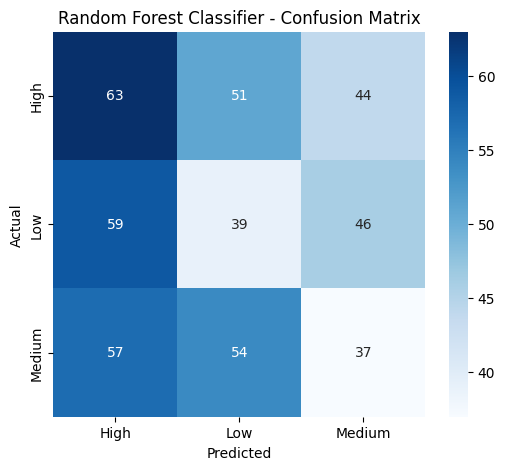

In [ ]:
cm = confusion_matrix(
    y_val_cls,
    rf_val_preds_cls,
    labels=rf_clf.named_steps["model"].classes_
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=rf_clf.named_steps["model"].classes_,
    yticklabels=rf_clf.named_steps["model"].classes_
)
plt.title("Random Forest Classifier - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

To further investigate whether the problem formulation was limiting performance, the task was reformulated as a classification problem by grouping financial losses into three categories: Low, Medium, and High. Logistic Regression and Random Forest classifiers were trained and evaluated on this formulation. Both models achieved accuracy scores of approximately 31% and macro F1 scores near 0.31, which is comparable to random guessing for a three-class problem. The confusion matrix further confirmed that predictions were distributed across all classes with no strong diagonal pattern, indicating that the models were unable to reliably distinguish between categories. These results reinforce the conclusion that the available features contain limited predictive signal, even when the problem is simplified.

## Step 8: Feature Interaction Experiment

In [ ]:
# Create interaction feature
df["Attack_Industry"] = df["Attack Type"] + "_" + df["Target Industry"]

df[["Attack Type", "Target Industry", "Attack_Industry"]].head()

# Create new feature matrix (with interaction)
X_interaction = df.drop(columns=["Financial Loss (in Million $)"])
y_interaction = df["Financial Loss (in Million $)"]

# Split interaction dataset
X_train_int = X_interaction.loc[X_train.index]
X_val_int = X_interaction.loc[X_val.index]
X_test_int = X_interaction.loc[X_test.index]

y_train_int = y.loc[y_train.index]
y_val_int = y.loc[y_val.index]
y_test_int = y.loc[y_test.index]
# Train Random Forest with interaction
rf_int = Pipeline([
    ("preprocess", preprocess_unscaled),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ))
])

rf_int.fit(X_train_int, y_train_int)

rf_val_preds_int = rf_int.predict(X_val_int)

rf_int_mae = mean_absolute_error(y_val_int, rf_val_preds_int)
rf_int_rmse = np.sqrt(mean_squared_error(y_val_int, rf_val_preds_int))
rf_int_r2 = r2_score(y_val_int, rf_val_preds_int)

print("=== Random Forest WITH Interaction Feature ===")
print(f"MAE: {rf_int_mae:.4f}")
print(f"RMSE: {rf_int_rmse:.4f}")
print(f"R^2: {rf_int_r2:.4f}")

# Compare results
comparison = pd.DataFrame({
    "Model": ["Random Forest (Original)", "Random Forest (With Interaction)"],
    "MAE": [best_rf_entry["MAE"], rf_int_mae],
    "RMSE": [best_rf_entry["RMSE"], rf_int_rmse],
    "R^2": [best_rf_entry["R^2"], rf_int_r2]
})

print("=== Interaction Feature Impact ===")
display(comparison)

=== Random Forest WITH Interaction Feature ===
MAE: 24.1090
RMSE: 28.1705
R^2: -0.0290
=== Interaction Feature Impact ===


,Model,MAE,RMSE,R^2
0,Random Forest (Original),23.999439,28.087590,-0.022922
1,Random Forest (With Interaction),24.108958,28.170547,-0.028973


To examine whether feature interactions could improve predictive performance, an interaction feature combining attack type and target industry was introduced. This feature allowed the model to explicitly capture patterns specific to attack-industry combinations. However, incorporating this interaction did not improve model performance; in fact, a slight decrease in performance was observed. This suggests that even when accounting for potential interactions, the available features do not provide sufficient predictive signal for accurately estimating financial loss.

## Conclusion:
Across multiple experiments, including baseline comparisons, regression modeling, classification reformulation, and interaction feature engineering, the models consistently failed to achieve meaningful predictive performance. Regression models performed similarly to simple baselines, while classification models achieved accuracy close to random guessing. Additionally, explicitly modeling feature interactions did not yield improvements. These results strongly suggest that the available features in the dataset contain limited predictive signal for estimating financial loss, and that important explanatory variables may be missing or the target variable may be inherently noisy.